# Wind-Turbine Gearbox Health Explorer — model development

**BITS Pilani WILP · M.Tech (AI/ML) · Machine Learning Assignment 2**

This notebook documents the full modelling workflow behind the Streamlit app:

1. Load the extracted condition-monitoring feature table
2. Look at how separable the classes actually are
3. Show *why* the plain binary health task was rejected as the target
4. Train and compare the six required classifiers
5. Analyse where the errors actually fall

Run `python feature_extraction.py --raw ../data --outdir ..` first if
`train_data.csv` / `test_data.csv` do not exist yet.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, ".")
from train_models import build_model_zoo, evaluate, CLASS_ORDER, METRIC_ORDER, TARGET_COLUMN

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)

ROOT = Path("..")
train_df = pd.read_csv(ROOT / "train_data.csv")
test_df  = pd.read_csv(ROOT / "test_data.csv")

features = [c for c in train_df.columns if c != TARGET_COLUMN]
X_train, y_train = train_df[features], train_df[TARGET_COLUMN]
X_test,  y_test  = test_df[features],  test_df[TARGET_COLUMN]

print(f"train windows : {len(X_train)}")
print(f"test  windows : {len(X_test)}")
print(f"features      : {len(features)}")
print(f"classes       : {len(y_train.unique())}")

train windows : 2753
test  windows : 1188
features      : 36
classes       : 6


## 1 · Class balance

The six states are reasonably balanced, so plain accuracy is a fair headline
metric — but MCC is still reported because it is the metric that degrades
honestly if any class collapses.

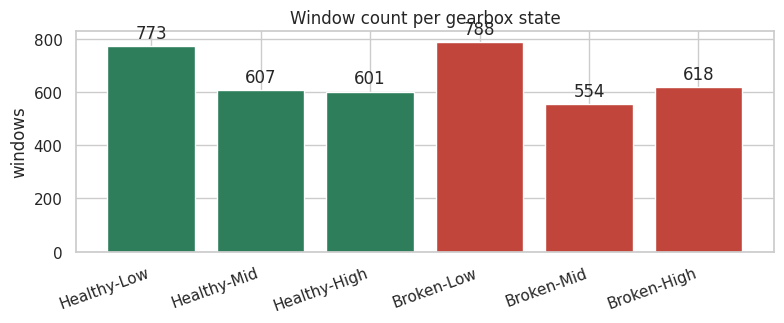

,windows
gearbox_state,
Healthy-Low,773
Healthy-Mid,607
Healthy-High,601
Broken-Low,788
Broken-Mid,554
Broken-High,618


In [2]:
counts = (pd.concat([y_train, y_test])
            .value_counts()
            .reindex(CLASS_ORDER))

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.bar(counts.index, counts.values,
              color=["#2E7D5B"] * 3 + ["#C1453B"] * 3)
ax.bar_label(bars, padding=3)
ax.set_ylabel("windows")
ax.set_title("Window count per gearbox state")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

counts.to_frame("windows")

## 2 · How separable is the health state?

Plotting mean RMS on accelerometer 1 against load makes the problem obvious:
the healthy and broken-tooth curves never come close to touching at *any* load.

Note the direction — the *healthy* rig vibrates **more** than the damaged one.
That is not physics; it is an artefact of the two recordings being captured in
separate campaigns with different sensor mounting/gain. It is precisely why the
binary task is trivial here, and why it makes a poor target for comparing
models.

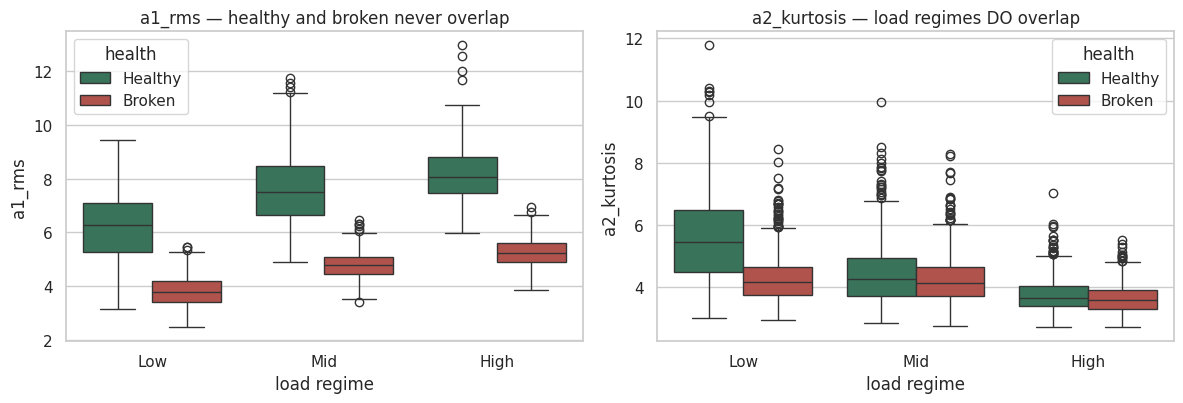

In [3]:
raw = pd.concat([train_df, test_df], ignore_index=True)
raw["health"] = raw[TARGET_COLUMN].str.split("-").str[0]
raw["regime"] = raw[TARGET_COLUMN].str.split("-").str[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.boxplot(data=raw, x="regime", y="a1_rms", hue="health",
            order=["Low", "Mid", "High"],
            palette={"Healthy": "#2E7D5B", "Broken": "#C1453B"}, ax=axes[0])
axes[0].set_title("a1_rms — healthy and broken never overlap")
axes[0].set_xlabel("load regime")

sns.boxplot(data=raw, x="regime", y="a2_kurtosis", hue="health",
            order=["Low", "Mid", "High"],
            palette={"Healthy": "#2E7D5B", "Broken": "#C1453B"}, ax=axes[1])
axes[1].set_title("a2_kurtosis — load regimes DO overlap")
axes[1].set_xlabel("load regime")

plt.tight_layout(); plt.show()

The left panel is why binary health classification is solved. The right panel
is where the difficulty actually lives: **telling the load regimes apart**, which
is what the six-class target forces the models to do.

## 3 · Rejecting the binary target

Confirming the claim numerically — every model is at or near 100 % on the
health-only problem, so that table cannot rank anything.

In [4]:
to_health = lambda s: s.str.split("-").str[0]

from sklearn.metrics import accuracy_score, matthews_corrcoef

binary_rows = {}
for name, pipe in build_model_zoo().items():
    pipe.fit(X_train, to_health(y_train))
    pred = pipe.predict(X_test)
    binary_rows[name] = {
        "Accuracy": accuracy_score(to_health(y_test), pred),
        "MCC": matthews_corrcoef(to_health(y_test), pred),
    }

pd.DataFrame(binary_rows).T.round(4)

,Accuracy,MCC
Logistic Regression,1.0000,1.0000
Decision Tree,1.0000,1.0000
kNN,0.9992,0.9983
Naive Bayes,1.0000,1.0000
Random Forest (Ensemble),1.0000,1.0000
Support Vector Machine,1.0000,1.0000


## 4 · Training the six models on the six-class target

Each model is a `Pipeline(StandardScaler -> estimator)`, so the scaler travels
with the model and the Streamlit app never has to reconstruct preprocessing
state.

In [5]:
fitted, results = {}, {}

for name, pipe in build_model_zoo().items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results[name] = evaluate(pipe, X_test, y_test)
    print(f"{name:<26} done")

comparison = pd.DataFrame(results).T[METRIC_ORDER].round(4)
comparison.index.name = "ML Model Name"
comparison

Logistic Regression        done
Decision Tree              done
kNN                        done


Naive Bayes                done


Random Forest (Ensemble)   done


Support Vector Machine     done


,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.8872,0.9883,0.8801,0.8822,0.8803,0.8646
Decision Tree,0.7862,0.9188,0.7754,0.7756,0.7751,0.7428
kNN,0.8418,0.9737,0.8327,0.8349,0.8326,0.8101
Naive Bayes,0.7988,0.9704,0.7900,0.7933,0.7884,0.7594
Random Forest (Ensemble),0.8754,0.9863,0.8672,0.8685,0.8672,0.8503
Support Vector Machine,0.8830,0.9882,0.8752,0.8760,0.8748,0.8594


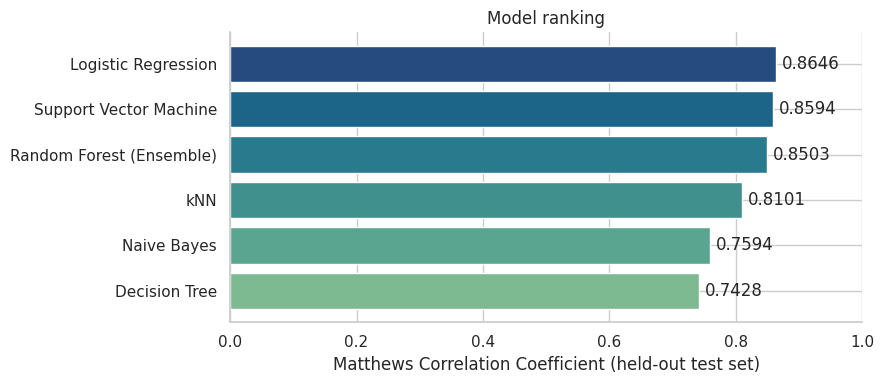

In [6]:
ranked = comparison.sort_values("MCC")

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(ranked.index, ranked["MCC"],
               color=sns.color_palette("crest", len(ranked)))
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Matthews Correlation Coefficient (held-out test set)")
ax.set_title("Model ranking")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 5 · Where do the errors fall?

Six confusion matrices side by side. The striking pattern: every matrix is
**block-diagonal** — the top-left 3×3 (healthy states) and bottom-right 3×3
(broken states) contain essentially all the mass.

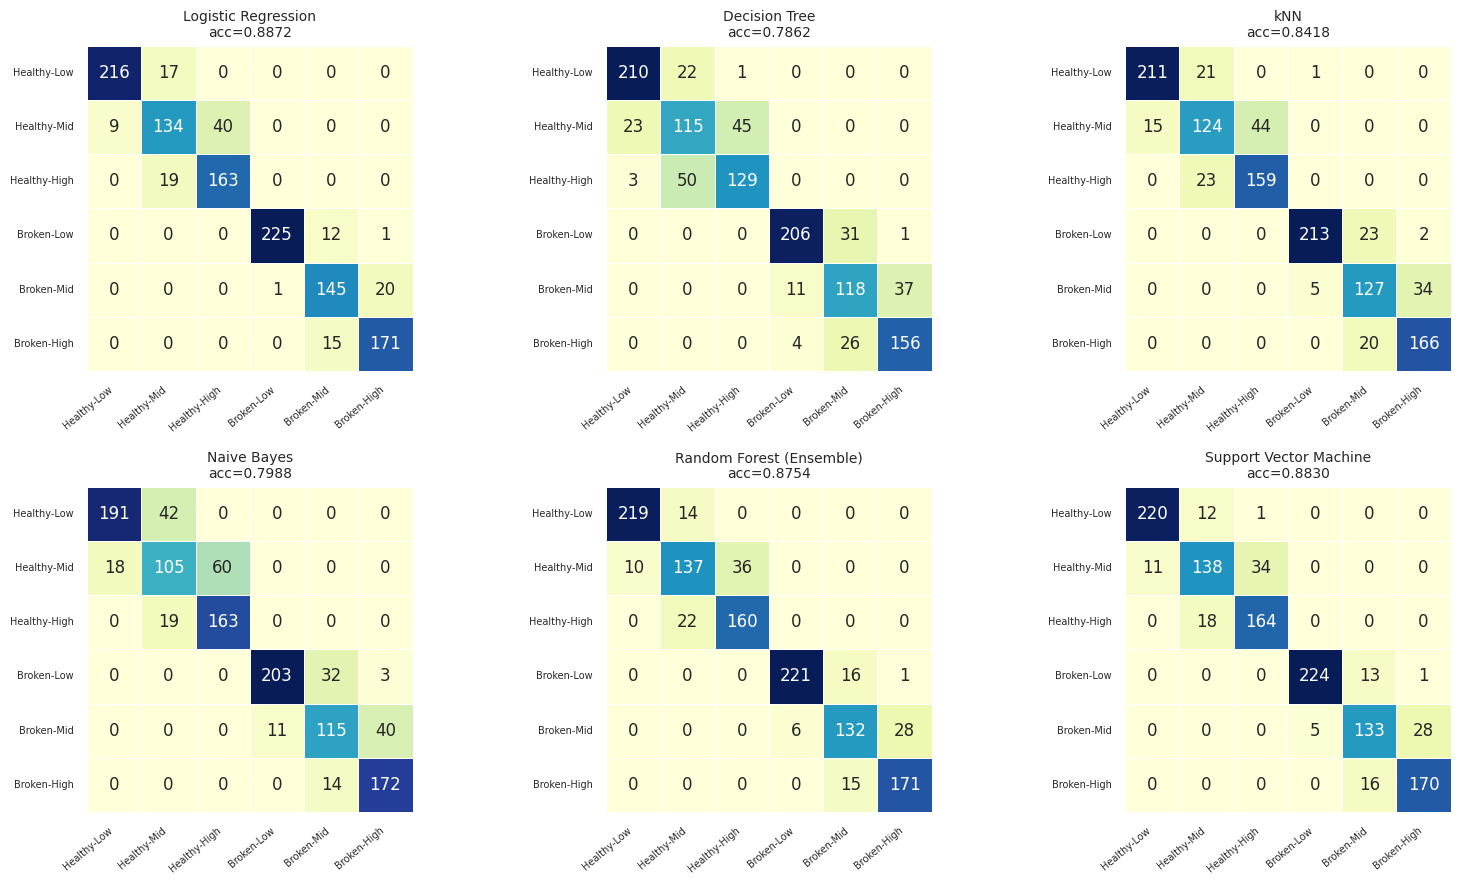

In [7]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (name, pipe) in zip(axes.ravel(), fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test), labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False, square=True,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                linewidths=.5, linecolor="white", ax=ax)
    ax.set_title(f"{name}\nacc={comparison.loc[name, 'Accuracy']:.4f}", fontsize=10)
    ax.tick_params(labelsize=7)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right")

plt.tight_layout(); plt.show()

In [8]:
health_idx = [i for i, c in enumerate(CLASS_ORDER) if c.startswith("Healthy")]
broken_idx = [i for i, c in enumerate(CLASS_ORDER) if c.startswith("Broken")]

rows = []
for name, pipe in fitted.items():
    cm = confusion_matrix(y_test, pipe.predict(X_test), labels=CLASS_ORDER)
    crossing = cm[np.ix_(health_idx, broken_idx)].sum() + cm[np.ix_(broken_idx, health_idx)].sum()
    total_err = cm.sum() - np.trace(cm)
    rows.append({
        "Model": name,
        "Total errors": int(total_err),
        "Cross health boundary": int(crossing),
        "Load-regime confusions": int(total_err - crossing),
    })

pd.DataFrame(rows).set_index("Model")

,Total errors,Cross health boundary,Load-regime confusions
Model,,,
Logistic Regression,134,0,134
Decision Tree,254,0,254
kNN,188,1,187
Naive Bayes,239,0,239
Random Forest (Ensemble),148,0,148
Support Vector Machine,139,0,139


**This is the headline finding.** Out of 1,188 test windows, the number of
misclassifications that mistake a broken gearbox for a healthy one (or vice
versa) is 0 or 1 for every model. All residual error is load-regime confusion.

For a condition monitoring system that is the ideal failure mode: the model may
be unsure which operating point a reading came from, but it never misses the
fault.

## 6 · Reading the winning model

Logistic Regression came first, so its coefficients can be inspected directly.
Aggregating the absolute multinomial coefficients per feature shows which
descriptors carry the load-regime signal.

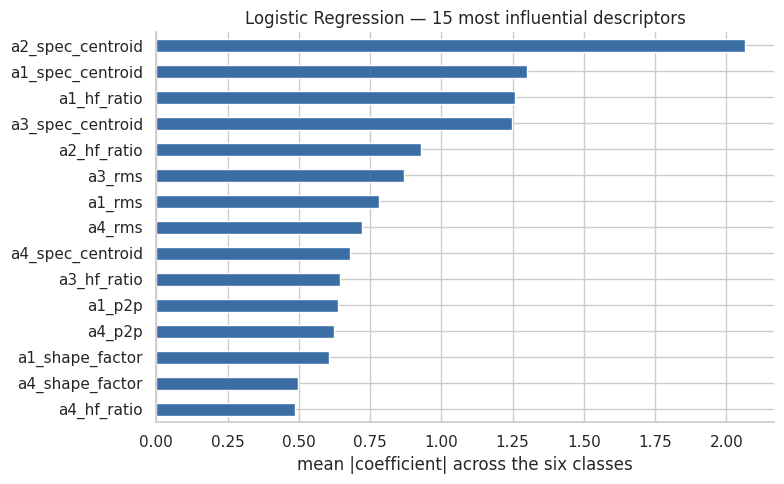

,mean |coef|
a2_spec_centroid,2.064
a1_spec_centroid,1.299
a1_hf_ratio,1.258
a3_spec_centroid,1.249
a2_hf_ratio,0.928
a3_rms,0.870
a1_rms,0.783
a4_rms,0.722
a4_spec_centroid,0.681
a3_hf_ratio,0.646


In [9]:
lr = fitted["Logistic Regression"]
coef = np.abs(lr.named_steps["clf"].coef_).mean(axis=0)

importance = (pd.Series(coef, index=features)
                .sort_values(ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
importance.sort_values().plot.barh(ax=ax, color="#3B6EA5")
ax.set_xlabel("mean |coefficient| across the six classes")
ax.set_title("Logistic Regression — 15 most influential descriptors")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

importance.round(3).to_frame("mean |coef|")

## 7 · Conclusion

| | |
|---|---|
| **Winner** | Logistic Regression — best on all six metrics (Acc 0.8872, MCC 0.8646) |
| **Close second** | Support Vector Machine (RBF), statistically indistinguishable |
| **Best no-tuning default** | Random Forest — 9 MCC points above the single tree it is built from |
| **Weakest** | Decision Tree, especially on AUC (0.9188) — coarse leaf probabilities |

The broader lesson: on this dataset the heavy lifting was done by **feature
extraction**, not by the classifier. Once the raw vibration stream is reduced to
36 well-chosen condition-monitoring descriptors, the class structure is close to
linearly separable, and the simplest model in the comparison wins.

Artefacts consumed by the Streamlit app are written by `train_models.py` into
`model/saved/`.